# Imports

In [1]:
from pathlib import Path
import re
from experimaestro.settings import get_workspace

import numpy as np
import matplotlib.pyplot as plt
#use ACM style

FONT_SIZE = 14

# Set font for publication quality
# plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.family'] = 'DejaVu Serif'
# plt.rcParams['font.serif'] = ['']
plt.rcParams['font.size'] = FONT_SIZE
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = FONT_SIZE
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = FONT_SIZE

plt.style.use('ggplot')


#default_workspace_path 
ws = get_workspace()
xps_root = ws.path / "experiments"

def get_last_xp(xp_id, force_date=None):
    dates = list((xps_root / xp_id).glob("*"))
    print(f"Found dates for {xp_id}: {[d.name for d in dates]}")
    
    #parse and get most recent date
    if force_date is not None:
        forced_date_path = xps_root / xp_id / force_date
        if forced_date_path in dates:
            most_recent_date = forced_date_path
            print(f"Using forced date for {xp_id}: {most_recent_date.name}")
            return most_recent_date
        else:
            print(f"Forced date {force_date} not found for xp {xp_id}")
        
    dates = [d for d in dates if re.match(r'\d+_\d+', d.name)]

    if len(dates) == 0:
        print(f"No valid dates found for xp {xp_id}, returning dry-run")
        return xps_root / xp_id / "dry-run"
    
    most_recent_date = max(dates, key=lambda d: d.name)
    
    print(f"Most recent date for {xp_id}: {most_recent_date.name}")
    
    return most_recent_date


def process_results(results):
    labels1 = results.iloc[0]
    labels2 = results.iloc[1]
    labels = [f"{l1}{ '_' + str(l2) if str(l2) != 'nan' else ''}" for l1, l2 in zip(labels1, labels2)]
    labels[0] = 'dataset'
    results.columns = labels
    return results.iloc[2:]

def get_aggregated_stats(results, group_cols, metrics):
        # 3. Ensure numeric types
        all_cols = []
        for m in metrics:
            all_cols.extend([f'{m}_mean', f'{m}_var'])

        for col in all_cols:
            results[col] = pd.to_numeric(results[col], errors='coerce')

        # 4. Compute the Simple Average of Means and Variances
        #    We do NOT add the inter-dataset variance here.
        #    We act as if the datasets are fixed strata.
        aggregated_stats = results.groupby(group_cols, dropna=False)[all_cols].mean()

        # 5. Rename columns for clarity
        #    Renaming 'AP_mean' -> 'Grand_Mean_AP' and 'AP_var' -> 'Average_Var_AP'
        rename_dict = {}
        for m in metrics:
            rename_dict[f'{m}_mean'] = f'{m}_Grand_Mean'
            rename_dict[f'{m}_var']  = f'{m}_Average_Var'

        aggregated_stats = aggregated_stats.rename(columns=rename_dict)
        
        return aggregated_stats
        # Add experiment label


print("found xps")
all_xps = list(xps_root.glob("*"))
for xp in all_xps:
    print(f"- {xp}") 


/home/morand/code/franken_minilm/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


found xps
- /home/morand/experiments/cross_encoders/experiments/minilm_l12_step3_merge_layer
- /home/morand/experiments/cross_encoders/experiments/debug_midFusion_minilm_mse_v2
- /home/morand/experiments/cross_encoders/experiments/eval_masked_step0
- /home/morand/experiments/cross_encoders/experiments/eval_masked_step1
- /home/morand/experiments/cross_encoders/experiments/midFusion_minilm_l6_drop_search
- /home/morand/experiments/cross_encoders/experiments/minilm_l12_step1
- /home/morand/experiments/cross_encoders/experiments/minilm_l12_step2
- /home/morand/experiments/cross_encoders/experiments/ettin_masking_step1
- /home/morand/experiments/cross_encoders/experiments/eval_masked_step2
- /home/morand/experiments/cross_encoders/experiments/minilm_l12_step3
- /home/morand/experiments/cross_encoders/experiments/minilm_l12_reproduction_schlatt2024
- /home/morand/experiments/cross_encoders/experiments/midFusion_minilm_l6_randomhead
- /home/morand/experiments/cross_encoders/experiments/minil

In [2]:
import matplotlib.pyplot as plt
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

# Figure 1

In [16]:
import re 
import pandas as pd
from IPython.display import display

xps = [
    # "minilm_l12_step3_merge_layer",
    # "ettin_17M_search_merge_layer",
    "ettin_32M_search_merge_layer",
] 


## Process results

In [17]:

def get_results(xp, force_date=None):
    most_recent_date = get_last_xp(xp, force_date)
    res_path = xps_root / xp / most_recent_date / "results"
    results_files = list(res_path.glob("*.csv"))
    print(f"Found results files for {xp}: {[f.name for f in results_files]}")
    results = pd.read_csv(res_path / "results.csv")
    labels1 = results.iloc[0]
    labels2 = results.iloc[1]
    labels = [f"{l1}{ '_' + l2 if str(l2) != 'nan' else ''}" for l1, l2 in zip(labels1, labels2)]
    labels[0] = 'dataset'
    results.columns = labels
    results = results.iloc[2:]

    #get drop layer from grid search column
    pattern = re.compile(r'l\d-(\d+)')
    results['merge_layer'] = results['grid_search'].apply(lambda x: int(pattern.search(x).group(1)) if isinstance(x, str) and pattern.search(x) else None)


    stats = pd.read_csv(res_path / "statistical_significance_results.csv")

    return results, stats

for xp in xps:
    # drop first row of results
    print("Results:")
    results, stats = get_results(
        xp,
        force_date = "dry-run"
        )
    display(results.head())
    print("Statistical Significance Results:")
    display(stats)
    

# 1. Define the metrics
metrics = ['AP', 'RR@10', 'nDCG@10']

metric_to_plot = 'nDCG@10'
# 2. Define the configuration columns
group_cols = ['first_stage', 'scorer', 'grid_search', 'merge_layer']

# 3. Ensure numeric types
all_cols = []
for m in metrics:
    all_cols.extend([f'{m}_mean', f'{m}_var'])

for col in all_cols:
    results[col] = pd.to_numeric(results[col], errors='coerce')

# 4. Compute the Simple Average of Means and Variances
#    We do NOT add the inter-dataset variance here.
#    We act as if the datasets are fixed strata.
aggregated_stats = results.groupby(group_cols, dropna=False)[all_cols].mean()

# 5. Rename columns for clarity
#    Renaming 'AP_mean' -> 'Grand_Mean_AP' and 'AP_var' -> 'Average_Var_AP'
rename_dict = {}
for m in metrics:
    rename_dict[f'{m}_mean'] = f'{m}_Grand_Mean'
    rename_dict[f'{m}_var']  = f'{m}_Average_Var'

aggregated_stats = aggregated_stats.rename(columns=rename_dict)

print(f"""found {len(results)} evals on datasets: 
      {', '.join(results['dataset'].unique())}""")

print("Aggregated Results (Average Variance only):")
display(aggregated_stats)


Results:
Found dates for ettin_32M_search_merge_layer: ['20260114_193105', 'dry-run', 'lock']
Most recent date for ettin_32M_search_merge_layer: 20260114_193105
Using forced date for ettin_32M_search_merge_layer: dry-run
Found results files for ettin_32M_search_merge_layer: ['results.csv', 'statistical_significance_results.csv']


,dataset,first_stage,scorer,grid_search,AP_mean,AP_var,RR@10_mean,RR@10_var,nDCG@10_mean,nDCG@10_var,merge_layer
2,msmarco_dev,bm25,NaN,NaN,0.1942,NaN,0.1855,NaN,0.2301,NaN,NaN
3,msmarco_dev,bm25,baseline-ettin_32M_search_merge_layer-0,attn_['query']2['document']_l0-0,0.36662,4.6156987e-05,0.36294,5.0743023e-05,0.42334,4.5913133e-05,0.0
4,msmarco_dev,bm25,ettin_32M_search_merge_layer-1,attn_['query']2['document']_l0-1,0.3599,0.00015005998,0.35586,0.00015954295,0.41599998,0.00017471501,1.0
5,msmarco_dev,bm25,ettin_32M_search_merge_layer-2,attn_['query']2['document']_l0-2,0.3653,6.3760075e-05,0.36138,6.7466994e-05,0.42209998,7.4410105e-05,2.0
6,msmarco_dev,bm25,ettin_32M_search_merge_layer-3,attn_['query']2['document']_l0-3,0.36076,0.00020141312,0.35683998,0.00021824791,0.41679996,0.00024688506,3.0


Statistical Significance Results:


,dataset,measure,model,t_stat,p_value,n_baseline,n_other
0,msmarco_dev,AP,ettin_32M_search_merge_layer-1-RR@10,1.076246,2.818360e-01,6980,6980
1,msmarco_dev,AP,ettin_32M_search_merge_layer-2-RR@10,0.210247,8.334781e-01,6980,6980
2,msmarco_dev,AP,ettin_32M_search_merge_layer-3-RR@10,0.941252,3.465922e-01,6980,6980
3,msmarco_dev,AP,ettin_32M_search_merge_layer-4-RR@10,0.181356,8.560905e-01,6980,6980
4,msmarco_dev,AP,ettin_32M_search_merge_layer-5-RR@10,0.609866,5.419605e-01,6980,6980
...,...,...,...,...,...,...,...
76,trec2020,nDCG@10,ettin_32M_search_merge_layer-5-RR@10,-0.059831,9.524030e-01,54,54
77,trec2020,nDCG@10,ettin_32M_search_merge_layer-6-RR@10,-0.011676,9.907062e-01,54,54
78,trec2020,nDCG@10,ettin_32M_search_merge_layer-7-RR@10,0.862576,3.903471e-01,54,54
79,trec2020,nDCG@10,ettin_32M_search_merge_layer-8-RR@10,1.268447,2.074874e-01,54,54


found 33 evals on datasets: 
      msmarco_dev, trec2019, trec2020
Aggregated Results (Average Variance only):


AP_Grand_Mean  \
first_stage scorer                                  grid_search                      merge_layer                  
bm25        baseline-ettin_32M_search_merge_layer-0 attn_['query']2['document']_l0-0 0.0               0.443867   
            ettin_32M_search_merge_layer-1          attn_['query']2['document']_l0-1 1.0               0.437033   
            ettin_32M_search_merge_layer-2          attn_['query']2['document']_l0-2 2.0               0.442107   
            ettin_32M_search_merge_layer-3          attn_['query']2['document']_l0-3 3.0               0.436240   
            ettin_32M_search_merge_layer-4          attn_['query']2['document']_l0-4 4.0               0.436953   
            ettin_32M_search_merge_layer-5          attn_['query']2['document']_l0-5 5.0               0.434620   
            ettin_32M_search_merge_layer-6          attn_['query']2['document']_l0-6 6.0               0.433280   
            ettin_32M_search_merge_layer-7          attn_['query']2['document']_l0-7 7.0               0.406013   
            ettin_32M_search_merge_layer-8          attn_['query']2['document']_l0-8 8.0               0.405547   
            ettin_32M_search_merge_layer-9          attn_['query']2['document']_l0-9 9.0               0.041500   
            NaN                                     NaN                              NaN               0.305633   

                                                                                                  AP_Average_Var  \
first_stage scorer                                  grid_search                      merge_layer                   
bm25        baseline-ettin_32M_search_merge_layer-0 attn_['query']2['document']_l0-0 0.0                0.000053   
            ettin_32M_search_merge_layer-1          attn_['query']2['document']_l0-1 1.0                0.000122   
            ettin_32M_search_merge_layer-2          attn_['query']2['document']_l0-2 2.0                0.000061   
            ettin_32M_search_merge_layer-3          attn_['query']2['document']_l0-3 3.0                0.000180   
            ettin_32M_search_merge_layer-4          attn_['query']2['document']_l0-4 4.0                0.000004   
            ettin_32M_search_merge_layer-5          attn_['query']2['document']_l0-5 5.0                0.000025   
            ettin_32M_search_merge_layer-6          attn_['query']2['document']_l0-6 6.0                0.000027   
            ettin_32M_search_merge_layer-7          attn_['query']2['document']_l0-7 7.0                0.000012   
            ettin_32M_search_merge_layer-8          attn_['query']2['document']_l0-8 8.0                0.000007   
            ettin_32M_search_merge_layer-9          attn_['query']2['document']_l0-9 9.0                0.000000   
            NaN                                     NaN                              NaN                     NaN   

                                                                                                  RR@10_Grand_Mean  \
first_stage scorer                                  grid_search                      merge_layer                     
bm25        baseline-ettin_32M_search_merge_layer-0 attn_['query']2['document']_l0-0 0.0                  0.749260   
            ettin_32M_search_merge_layer-1          attn_['query']2['document']_l0-1 1.0                  0.740553   
            ettin_32M_search_merge_layer-2          attn_['query']2['document']_l0-2 2.0                  0.742620   
            ettin_32M_search_merge_layer-3          attn_['query']2['document']_l0-3 3.0                  0.737753   
            ettin_32M_search_merge_layer-4          attn_['query']2['document']_l0-4 4.0                  0.746647   
            ettin_32M_search_merge_layer-5          attn_['query']2['document']_l0-5 5.0                  0.748533   
            ettin_32M_search_merge_layer-6          attn_['query']2['document']_l0-6 6.0                  0.746913   
            ettin_32M_search_me

## Plotting Layer Merge 

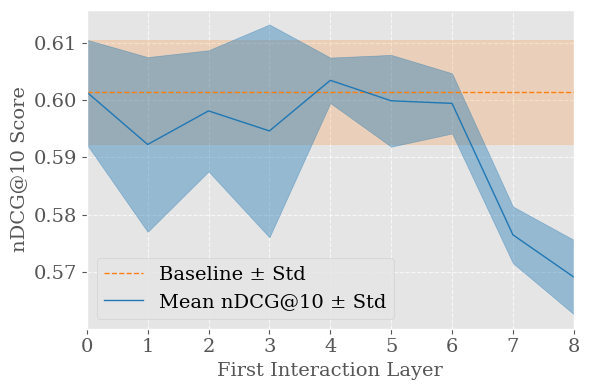

In [18]:
# --- PLOTTING (Updated for this logic) ---

# Filter for plotting
plot_df = aggregated_stats.reset_index()
#keep only rows with merge_layer not null, sort by merge_layer
plot_df = plot_df[plot_df['merge_layer'].notnull()].sort_values(by='merge_layer')

# Calculate Average Standard Deviation (approx) from the Average Variance
# Note: Average(Std) != Sqrt(Average(Var)), but for error bars, Sqrt(Avg_Var) is the standard estimator for "Root Mean Square Error"
plot_df['nDCG_std_est'] = np.sqrt(plot_df[f'{metric_to_plot}_Average_Var'])

fig, ax = plt.subplots(figsize=(6, 4))

EXCLUDE_LAST = True

if EXCLUDE_LAST:
    plot_df = plot_df.iloc[:-1]

#plot baseline as horizontal line - baseline is first row 
baseline_value = plot_df[f'{metric_to_plot}_Grand_Mean'].iloc[0]
baseline_std_est = np.sqrt(plot_df[f'{metric_to_plot}_Average_Var'].iloc[0])
ax.axhline(
    y=baseline_value,
    color='tab:orange',
    linestyle='--',
    linewidth=1,
    label='Baseline ± Std'
)
#also plot shaded area for baseline std
ax.fill_between(
    plot_df['merge_layer'],
    baseline_value - baseline_std_est,
    baseline_value + baseline_std_est,
    color='tab:orange',
    alpha=0.2,
)   


# shaded envelope for mean ± estimated std
ax.fill_between(
    plot_df['merge_layer'],
    plot_df[f'{metric_to_plot}_Grand_Mean'] - plot_df['nDCG_std_est'],
    plot_df[f'{metric_to_plot}_Grand_Mean'] + plot_df['nDCG_std_est'],
    color='tab:blue',
    alpha=0.4,
)

ax.plot(
    plot_df['merge_layer'],
    plot_df[f'{metric_to_plot}_Grand_Mean'],
    '-',
    linewidth=1,
    color='tab:blue',
    label=f'Mean {metric_to_plot} ± Std'
 )

v_min, v_max = plot_df['merge_layer'].min(), plot_df['merge_layer'].max()

# ax.set_title(f'MiniLM - Average ID {metric_to_plot} vs Merge Layer')
ax.set_xlabel('First Interaction Layer', fontsize=FONT_SIZE)
ax.set_xlim(v_min, v_max)
# ax.set_ylim(0.4, 0.55)
ax.set_ylabel(f'{metric_to_plot} Score', fontsize=FONT_SIZE)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()
plt.tight_layout()
plt.show()

#save as pdf 
backbone = "ettin" if "ettin" in xps[0] else "minilm"
fig.savefig(f'figures/{backbone}_average_ID_{metric_to_plot}_vs_merge_layer.pdf')

# Layer drop XP

In [3]:
# Load both experiments
xps = [
    # "midFusion_minilm_l6_drop_search", 
    "midFusion_minilm_l4_drop_search",
    # "midFusion_ettin_32M_l4_drop_search",
    "midFusion_ettin_32M_l6_drop_search", 
    "midFusion_ettin_17M_l3_drop_search",
    ]


## Process

In [4]:
import pandas as pd
import re
from IPython.display import display

results_dict = {}

for xp in xps:
    #get max layer 
    if "minilm" in xp:
        N_LAYERS = 12
    elif "ettin_17M" in xp:
        N_LAYERS = 7
    elif "ettin_32M" in xp:
        N_LAYERS = 10
    else:
        raise ValueError(f"cannot find backbone type in xp: {xp}")

    most_recent_date = get_last_xp(xp)
    results_file = most_recent_date / "results" / "results.csv"
    if results_file.exists():
        print(f"Results for {xp}:")
        results = pd.read_csv(results_file)
        results_dict[xp] = (results, N_LAYERS)
        display(results.head())
    else:
        results_file = xps_root / xp / "dry-run"/ "results" / "results.csv"
        if results_file.exists():
            print(f"Results for {xp}:")
            results = pd.read_csv(results_file)
            results_dict[xp] = (results, N_LAYERS)
            display(results.head())
        else:
            print(f"No results found for {Path(xp)}.")

Found dates for midFusion_minilm_l4_drop_search: ['dry-run', '20260115_233921', '20260116_101745', 'lock', '20260116_162556', '20260116_165805']
Most recent date for midFusion_minilm_l4_drop_search: 20260116_165805
Results for midFusion_minilm_l4_drop_search:


,dataset,tag,tag.1,metric,metric.1,metric.2,metric.3,metric.4,metric.5
0,NaN,first_stage,scorer,AP,AP,RR@10,RR@10,nDCG@10,nDCG@10
1,NaN,NaN,NaN,mean,var,mean,var,mean,var
2,msmarco_dev,bm25,baseline-miniLM-compress=1_drop=0_merge=4,0.34761998,2.4197025e-05,0.35255998,4.016298e-05,0.40219998,1.3179997e-05
3,msmarco_dev,bm25,miniLM-compress=1_drop=10_merge=4,0.33698002,0.000104866995,0.3413,0.00017544483,0.39526,6.0483013e-05
4,msmarco_dev,bm25,miniLM-compress=1_drop=11_merge=4,0.34219998,5.956508e-05,0.34559998,0.00010261513,0.3989,5.839988e-05


Found dates for midFusion_ettin_32M_l6_drop_search: ['20260117_144904', '20260117_155041', 'dry-run', 'lock']
Most recent date for midFusion_ettin_32M_l6_drop_search: 20260117_155041
Results for midFusion_ettin_32M_l6_drop_search:


,dataset,tag,tag.1,metric,metric.1,metric.2,metric.3,metric.4,metric.5
0,NaN,first_stage,scorer,AP,AP,RR@10,RR@10,nDCG@10,nDCG@10
1,NaN,NaN,NaN,mean,var,mean,var,mean,var
2,msmarco_dev,bm25,baseline-ettin-drop=0_merge=6,0.36688,3.6020137e-06,0.36318,4.0570026e-06,0.4241,6.1150463e-06
3,msmarco_dev,bm25,ettin-drop=7_merge=6,0.0049400004,7.999971e-09,0.00024000001,3.000001e-09,0.00078,1.1999996e-08
4,msmarco_dev,bm25,ettin-drop=8_merge=6,0.35758,4.4806897e-05,0.35346,4.9347902e-05,0.4144,4.5735058e-05


Found dates for midFusion_ettin_17M_l3_drop_search: ['20260117_152529', '20260117_223306', '20260118_002700', 'dry-run', 'lock']
Most recent date for midFusion_ettin_17M_l3_drop_search: 20260118_002700
Results for midFusion_ettin_17M_l3_drop_search:


,dataset,tag,tag.1,metric,metric.1,metric.2,metric.3,metric.4,metric.5
0,NaN,first_stage,scorer,AP,AP,RR@10,RR@10,nDCG@10,nDCG@10
1,NaN,NaN,NaN,mean,var,mean,var,mean,var
2,msmarco_dev,bm25,baseline-ettin-drop=0_merge=3,0.3242,4.759997e-05,0.31884,5.527304e-05,0.37722,7.158713e-05
3,msmarco_dev,bm25,ettin-drop=4_merge=3,0.0049,1.9999923e-08,0.00019999998,5.0000013e-09,0.00076,1.2999998e-08
4,msmarco_dev,bm25,ettin-drop=5_merge=3,0.31448,3.198194e-05,0.30844,3.2952907e-05,0.36622,4.2517073e-05


In [5]:
from pathlib import Path 
import pandas as pd
import re 

metrics = ['AP', 'RR@10', 'nDCG@10']

processed_results = {}

for xp, (results, N_LAYERS) in results_dict.items():
    print(f"\n=== Processing {xp} ===")
    results = process_results(results).copy()

    #get drop layer from grid search column
    pattern = re.compile(r'drop=(\d+)_')

    def get_drop_layer(row):
        scorer = row['scorer']
        if "baseline" in scorer: return N_LAYERS
        try:
            match = pattern.search(scorer)
            return int(match.group(1))
        except:
            return None

    def get_merge_layer(row):
        scorer = row['scorer']
        try:
            match = re.compile(r'merge=(\d+)').search(scorer)
            return int(match.group(1))
        except: 
            return None

    def get_n_top(row):
        try:
            return row['drop_layer'] - row['merge_layer']
        except:
            return None
        

    results['drop_layer'] = results.apply(get_drop_layer, axis=1)
    results['merge_layer'] = results.apply(get_merge_layer, axis=1)
    results['n_top'] = results.apply(get_n_top, axis=1)
    results['n_dropped'] = results['drop_layer'].apply(lambda x: N_LAYERS - x if x is not None else None)

    display(results.sort_values(by='drop_layer', ascending=False))

    metric_to_plot = 'nDCG@10'
    # 2. Define the configuration columns
    group_cols = ['first_stage', 'scorer', 'drop_layer', 'n_dropped', 'merge_layer', 'n_top']

    aggregated_stats = get_aggregated_stats(results, group_cols, metrics)
    aggregated_stats['xp'] = xp
    
    processed_results[xp] = aggregated_stats

    print(f"Aggregated Results for {xp}:")
    display(aggregated_stats)


=== Processing midFusion_minilm_l4_drop_search ===


,dataset,first_stage,scorer,AP_mean,AP_var,RR@10_mean,RR@10_var,nDCG@10_mean,nDCG@10_var,drop_layer,merge_layer,n_top,n_dropped
2,msmarco_dev,bm25,baseline-miniLM-compress=1_drop=0_merge=4,0.34761998,2.4197025e-05,0.35255998,4.016298e-05,0.40219998,1.3179997e-05,12,4,8,0
10,trec2019,bm25,baseline-miniLM-compress=1_drop=0_merge=4,0.51423997,8.5131505e-06,0.97474,0.0001954278,0.73412,3.7861915e-05,12,4,8,0
18,trec2020,bm25,baseline-miniLM-compress=1_drop=0_merge=4,0.48680001,1.4649999e-06,0.93943995,8.475315e-05,0.70136,1.8792909e-05,12,4,8,0
4,msmarco_dev,bm25,miniLM-compress=1_drop=11_merge=4,0.34219998,5.956508e-05,0.34559998,0.00010261513,0.3989,5.839988e-05,11,4,7,1
12,trec2019,bm25,miniLM-compress=1_drop=11_merge=4,0.51398003,9.216972e-06,0.97366,9.858743e-05,0.73328,2.4546936e-05,11,4,7,1
20,trec2020,bm25,miniLM-compress=1_drop=11_merge=4,0.48529997,8.469976e-06,0.92888004,9.10266e-05,0.69904,8.420794e-05,11,4,7,1
3,msmarco_dev,bm25,miniLM-compress=1_drop=10_merge=4,0.33698002,0.000104866995,0.3413,0.00017544483,0.39526,6.0483013e-05,10,4,6,2
11,trec2019,bm25,miniLM-compress=1_drop=10_merge=4,0.5158,1.6635013e-05,0.97888005,6.2222054e-05,0.73786,7.887775e-05,10,4,6,2
19,trec2020,bm25,miniLM-compress=1_drop=10_merge=4,0.48624,4.653009e-06,0.93604004,4.2103e-05,0.7012,5.265097e-06,10,4,6,2
9,msmarco_dev,bm25,miniLM-compress=1_drop=9_merge=4,0.34372002,0.00013020197,0.3433,0.00017672002,0.39994,0.00011452292,9,4,5,3


Aggregated Results for midFusion_minilm_l4_drop_search:


AP_Grand_Mean  \
first_stage scorer                                    drop_layer n_dropped merge_layer n_top                  
bm25        baseline-miniLM-compress=1_drop=0_merge=4 12         0         4           8           0.449553   
            miniLM-compress=1_drop=10_merge=4         10         2         4           6           0.446340   
            miniLM-compress=1_drop=11_merge=4         11         1         4           7           0.447160   
            miniLM-compress=1_drop=5_merge=4          5          7         4           1           0.076107   
            miniLM-compress=1_drop=6_merge=4          6          6         4           2           0.349780   
            miniLM-compress=1_drop=7_merge=4          7          5         4           3           0.445300   
            miniLM-compress=1_drop=8_merge=4          8          4         4           4           0.447740   
            miniLM-compress=1_drop=9_merge=4          9          3         4           5           0.446713   

                                                                                              AP_Average_Var  \
first_stage scorer                                    drop_layer n_dropped merge_layer n_top                   
bm25        baseline-miniLM-compress=1_drop=0_merge=4 12         0         4           8            0.000011   
            miniLM-compress=1_drop=10_merge=4         10         2         4           6            0.000042   
            miniLM-compress=1_drop=11_merge=4         11         1         4           7            0.000026   
            miniLM-compress=1_drop=5_merge=4          5          7         4           1            0.000198   
            miniLM-compress=1_drop=6_merge=4          6          6         4           2            0.024679   
            miniLM-compress=1_drop=7_merge=4          7          5         4           3            0.000015   
            miniLM-compress=1_drop=8_merge=4          8          4         4           4            0.000063   
            miniLM-compress=1_drop=9_merge=4          9          3         4           5            0.000046   

                                                                                              RR@10_Grand_Mean  \
first_stage scorer                                    drop_layer n_dropped merge_layer n_top                     
bm25        baseline-miniLM-compress=1_drop=0_merge=4 12         0         4           8              0.755580   
            miniLM-compress=1_drop=10_merge=4         10         2         4           6              0.752073   
            miniLM-compress=1_drop=11_merge=4         11         1         4           7              0.749380   
            miniLM-compress=1_drop=5_merge=4          5          7         4           1              0.151873   
            miniLM-compress=1_drop=6_merge=4          6          6         4           2              0.613253   
            miniLM-compress=1_drop=7_merge=4          7          5         4           3              0.750320   
            miniLM-compress=1_drop=8_merge=4          8          4         4           4              0.750073   
            miniLM-compress=1_drop=9_merge=4          9          3         4           5              0.748973   

                                                                                              RR@10_Average_Var  \
first_stage scorer                                    drop_layer n_dropped merge_layer n_top                      
bm25        baseline-miniLM-compress=1_drop=0_merge=4 12         0         4           8               0.000107   
            miniLM-compress=1_drop=10_merge=4         10         2         4           6               0.000093   
            miniLM-compress=1_drop=11_merge=4         11         1         4           7               0.000097   
            miniLM-compress=1_drop=5_merge=4          5          7         4           1               0.001376   
            miniLM-compress=1_d


=== Processing midFusion_ettin_32M_l6_drop_search ===


...

AP_Grand_Mean  \
first_stage scorer                        drop_layer n_dropped merge_layer n_top                  
bm25        baseline-ettin-drop=0_merge=6 10         0         6           4           0.442607   
            ettin-drop=7_merge=6          7          3         6           1           0.038160   
            ettin-drop=8_merge=6          8          2         6           2           0.432400   
            ettin-drop=9_merge=6          9          1         6           3           0.438780   

                                                                                  AP_Average_Var  \
first_stage scorer                        drop_layer n_dropped merge_layer n_top                   
bm25        baseline-ettin-drop=0_merge=6 10         0         6           4            0.000007   
            ettin-drop=7_merge=6          7          3         6           1            0.000002   
            ettin-drop=8_merge=6          8          2         6           2            0.000059   
            ettin-drop=9_merge=6          9          1         6           3            0.000007   

                                                                                  RR@10_Grand_Mean  \
first_stage scorer                        drop_layer n_dropped merge_layer n_top                     
bm25        baseline-ettin-drop=0_merge=6 10         0         6           4              0.756680   
            ettin-drop=7_merge=6          7          3         6           1              0.043580   
            ettin-drop=8_merge=6          8          2         6           2              0.751587   
            ettin-drop=9_merge=6          9          1         6           3              0.748187   

                                                                                  RR@10_Average_Var  \
first_stage scorer                        drop_layer n_dropped merge_layer n_top                      
bm25        baseline-ettin-drop=0_merge=6 10         0         6           4               0.000153   
            ettin-drop=7_merge=6          7          3         6           1               0.000086   
            ettin-drop=8_merge=6          8          2         6           2               0.000056   
            ettin-drop=9_merge=6          9          1         6           3               0.000099   

                                                                                  nDCG@10_Grand_Mean  \
first_stage scorer                        drop_layer n_dropped merge_layer n_top                       
bm25        baseline-ettin-drop=0_merge=6 10         0         6           4                0.607373   
            ettin-drop=7_merge=6          7          3         6           1                0.014640   
            ettin-drop=8_merge=6          8          2         6           2                0.598753   
            ettin-drop=9_merge=6          9          1         6           3                0.598413   

                                                                                  nDCG@10_Average_Var  \
first_stage scorer                        drop_layer n_dropped merge_layer n_top                        
bm25        baseline-ettin-drop=0_merge=6 10         0         6           4                 0.000025   
            ettin-drop=7_merge=6          7          3         6           1                 0.000043   
            ettin-drop=8_merge=6          8          2         6           2                 0.000120   
            ettin-drop=9_merge=6          9          1         6           3                 0.000033   

                                                                                                                  xp  
first_stage scorer                        drop_layer n_dropped merge_layer n_top                                      
bm25        baseline-ettin-drop=0_merge=6 10         0         6           4      midFusion_ettin_32M_l6_drop_search  
            ettin-drop=7_merge=6         


=== Processing midFusion_ettin_17M_l3_drop_search ===


,dataset,first_stage,scorer,AP_mean,AP_var,RR@10_mean,RR@10_var,nDCG@10_mean,nDCG@10_var,drop_layer,merge_layer,n_top,n_dropped
2,msmarco_dev,bm25,baseline-ettin-drop=0_merge=3,0.3242,4.759997e-05,0.31884,5.527304e-05,0.37722,7.158713e-05,7,3,4,0
6,trec2019,bm25,baseline-ettin-drop=0_merge=3,0.44438,5.4246797e-05,0.91871995,0.00021063226,0.66084,3.3592816e-05,7,3,4,0
10,trec2020,bm25,baseline-ettin-drop=0_merge=3,0.42769998,9.8575096e-05,0.87321997,0.00023095706,0.62166,9.3462935e-05,7,3,4,0
5,msmarco_dev,bm25,ettin-drop=6_merge=3,0.32639998,6.0700527e-06,0.32096,7.163061e-06,0.3796,6.3399903e-06,6,3,3,1
13,trec2020,bm25,ettin-drop=6_merge=3,0.43322,3.6726855e-05,0.88336,0.00042284362,0.6245,0.00010588023,6,3,3,1
9,trec2019,bm25,ettin-drop=6_merge=3,0.45254,4.6617948e-05,0.91543996,0.000108807995,0.65698,0.0001421615,6,3,3,1
12,trec2020,bm25,ettin-drop=5_merge=3,0.41656,9.097322e-05,0.86535996,0.0006766275,0.6057,0.0003608751,5,3,2,2
4,msmarco_dev,bm25,ettin-drop=5_merge=3,0.31448,3.198194e-05,0.30844,3.2952907e-05,0.36622,4.2517073e-05,5,3,2,2
8,trec2019,bm25,ettin-drop=5_merge=3,0.43702,4.5272027e-05,0.9174601,0.00031858834,0.65436,0.0003221537,5,3,2,2
3,msmarco_dev,bm25,ettin-drop=4_merge=3,0.0049,1.9999923e-08,0.00019999998,5.0000013e-09,0.00076,1.2999998e-08,4,3,1,3


Aggregated Results for midFusion_ettin_17M_l3_drop_search:


AP_Grand_Mean  \
first_stage scorer                        drop_layer n_dropped merge_layer n_top                  
bm25        baseline-ettin-drop=0_merge=3 7          0         3           4           0.398760   
            ettin-drop=4_merge=3          4          3         3           1           0.037567   
            ettin-drop=5_merge=3          5          2         3           2           0.389353   
            ettin-drop=6_merge=3          6          1         3           3           0.404053   

                                                                                  AP_Average_Var  \
first_stage scorer                        drop_layer n_dropped merge_layer n_top                   
bm25        baseline-ettin-drop=0_merge=3 7          0         3           4            0.000067   
            ettin-drop=4_merge=3          4          3         3           1            0.000003   
            ettin-drop=5_merge=3          5          2         3           2            0.000056   
            ettin-drop=6_merge=3          6          1         3           3            0.000030   

                                                                                  RR@10_Grand_Mean  \
first_stage scorer                        drop_layer n_dropped merge_layer n_top                     
bm25        baseline-ettin-drop=0_merge=3 7          0         3           4              0.703593   
            ettin-drop=4_merge=3          4          3         3           1              0.046867   
            ettin-drop=5_merge=3          5          2         3           2              0.697087   
            ettin-drop=6_merge=3          6          1         3           3              0.706587   

                                                                                  RR@10_Average_Var  \
first_stage scorer                        drop_layer n_dropped merge_layer n_top                      
bm25        baseline-ettin-drop=0_merge=3 7          0         3           4               0.000166   
            ettin-drop=4_merge=3          4          3         3           1               0.000227   
            ettin-drop=5_merge=3          5          2         3           2               0.000343   
            ettin-drop=6_merge=3          6          1         3           3               0.000180   

                                                                                  nDCG@10_Grand_Mean  \
first_stage scorer                        drop_layer n_dropped merge_layer n_top                       
bm25        baseline-ettin-drop=0_merge=3 7          0         3           4                0.553240   
            ettin-drop=4_merge=3          4          3         3           1                0.013847   
            ettin-drop=5_merge=3          5          2         3           2                0.542093   
            ettin-drop=6_merge=3          6          1         3           3                0.553693   

                                                                                  nDCG@10_Average_Var  \
first_stage scorer                        drop_layer n_dropped merge_layer n_top                        
bm25        baseline-ettin-drop=0_merge=3 7          0         3           4                 0.000066   
            ettin-drop=4_merge=3          4          3         3           1                 0.000046   
            ettin-drop=5_merge=3          5          2         3           2                 0.000242   
            ettin-drop=6_merge=3          6          1         3           3                 0.000085   

                                                                                                                  xp  
first_stage scorer                        drop_layer n_dropped merge_layer n_top                                      
bm25        baseline-ettin-drop=0_merge=3 7          0         3           4      midFusion_ettin_17M_l3_drop_search  
            ettin-drop=4_merge=3         

## Plotting

Plotting experiment: midFusion_minilm_l4_drop_search
Plotting experiment: midFusion_ettin_32M_l6_drop_search
Plotting experiment: midFusion_ettin_17M_l3_drop_search


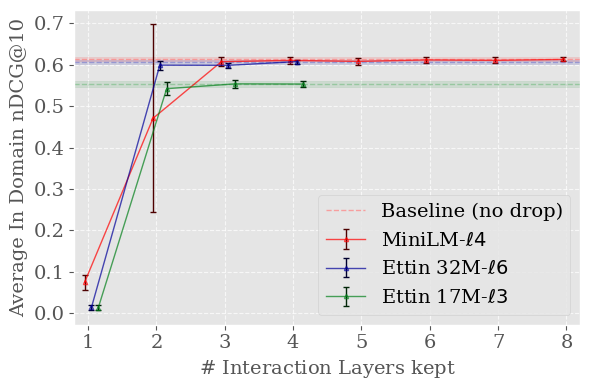

In [6]:
#plot both experiments on same figure

key = 'n_top'
MARGIN = 0.2
SHIFT = 0.1
metric_to_plot = 'nDCG@10'
FONT_SIZE = 14

fig, ax = plt.subplots(figsize=(6,4))

white = np.array((1, 1, 1, 1))
experiment_labels = {
    'midFusion_minilm_l6_drop_search':    r'MiniLM-$\ell 6$',
    'midFusion_minilm_l4_drop_search':    r'MiniLM-$\ell 4$',
    'midFusion_ettin_32M_l6_drop_search': r'Ettin 32M-$\ell 6$',
    'midFusion_ettin_32M_l4_drop_search': r'Ettin 32M-$\ell 4$',
    'midFusion_ettin_17M_l3_drop_search': r'Ettin 17M-$\ell 3$',
}

alpha = 0.7
experiment_colors = {
    'midFusion_minilm_l4_drop_search': np.array((1, 0, 0, alpha)), # red 
    'midFusion_minilm_l6_drop_search': np.array((1, 0.5, 0.1, alpha)), 
    'midFusion_ettin_32M_l6_drop_search': np.array((0, 0, 0.6, alpha)), # blue
    'midFusion_ettin_32M_l4_drop_search': np.array((0, 0, 0.6, alpha)), # blue
    'midFusion_ettin_17M_l3_drop_search': np.array((0.01, 0.5, 0.1, alpha)), # green
}

# Calculate min/max for margin
v_min = min([aggregated_stats.reset_index()[key].min() for aggregated_stats in processed_results.values()])
v_max = max([aggregated_stats.reset_index()[key].max() for aggregated_stats in processed_results.values()])

# Create x range for fill_between including margins
x_fill_range = np.linspace(v_min - MARGIN, v_max + MARGIN, 100)

for idx, (xp, aggregated_stats) in enumerate(processed_results.items()):
    print(f"Plotting experiment: {xp}")
    # Filter for plotting
    plot_df = aggregated_stats.reset_index()
    #keep only rows with drop_layer not null, sort by key
    plot_df = plot_df[plot_df['drop_layer'].notnull()].sort_values(by=key)
    
    # Calculate Average Standard Deviation (approx) from the Average Variance
    plot_df['nDCG_std_est'] = np.sqrt(plot_df[f'{metric_to_plot}_Average_Var'])
    
    color = experiment_colors[xp]
    label = experiment_labels[xp]
    
    # Plot baseline as horizontal line (first run with n_dropped == 0)
    baseline_row = plot_df[plot_df['n_dropped'] == 0].iloc[0]
    baseline_value = baseline_row[f'{metric_to_plot}_Grand_Mean']
    baseline_std_est = np.sqrt(baseline_row[f'{metric_to_plot}_Average_Var'])
    
    # Draw baseline for this experiment with same color and alpha=0.7
    ax.axhline(
        y=baseline_value,
        color=(color + white) / 2,
        linestyle='--',
        linewidth=1,
        alpha=0.7,
        label=f'Baseline (no drop)' if idx == 0 else None
        
    )
    #also plot shaded area for baseline std (including margins)
    ax.fill_between(
        x_fill_range,
        baseline_value - baseline_std_est,
        baseline_value + baseline_std_est,
        color=color,
        alpha=0.1,
    )
    x_vals = plot_df[key] + (idx - 0.5) * SHIFT
    # Plot error bars for this experiment
    ecolor = color * 0.3
    ecolor[-1] = 1.0  # ensure alpha is 1 for error bars
    ax.errorbar(
        x_vals,
        plot_df[f'{metric_to_plot}_Grand_Mean'],
        yerr=plot_df['nDCG_std_est'],
        linewidth=1,
        color=color,
        # darker version of color for error bars
        ecolor=ecolor,
        elinewidth=1,
        capsize=2,
        label=label,
        marker='^',
        markerfacecolor='none',
        markersize=3,
    )

# ax.set_title('Layer Dropping Experiments', fontsize=14)
ax.set_xlabel(r'$\#$ Interaction Layers kept', fontsize=FONT_SIZE)
ax.set_xlim(v_min - MARGIN, v_max + MARGIN)
ax.set_ylabel(f'Average In Domain {metric_to_plot}', fontsize=FONT_SIZE)
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_xticks(range(int(v_min), int(v_max) + 1))
ax.legend(fontsize=FONT_SIZE, loc='lower right')
plt.tight_layout()
plt.show()

backbone = 'ettin' if 'ettin' in xp else 'minilm'
fig.savefig(f'figures/all_layer_dropping_ID_{metric_to_plot}.pdf')

# Scaling law

In [81]:
# Load both experiments
xps_dict = {
    "midFusion_ettin_17M_l3_drop6": {
        "n_params": 16.9,
        "mice_n_params": 17.9,
    },
    "midFusion_ettin_32M_l6_drop9": {
        "n_params": 32,
        "mice_n_params": 34.4,
    }, 
    "midFusion_ettin_68M_l10_drop13": {
        "n_params": 68.4,
        "mice_n_params": 77.8,
    }, 
    "midFusion_ettin_150M_l11_drop14": {
        "n_params": 149.6,
        "mice_n_params": 175.6,
    }, 
}

xps = xps_dict.keys()

## Process

In [82]:
import pandas as pd
import re
from IPython.display import display

results_key = 'results'


for xp in xps:
    most_recent_date = get_last_xp(xp)
    
    if most_recent_date is None: most_recent_date = xp / "dry-run"
    results_file = most_recent_date / "results" / "results.csv"

    if results_file.exists():
        print(f"Results for {xp}:")
        results = process_results(
            pd.read_csv(results_file)
        ).copy()
        xps_dict[xp][results_key] = results
        # display(results.head())
        print(f"datasets in results: {results['dataset'].unique()}")
    else:
        raise ValueError(f"No results found for {Path(xp)}.")
    


Found dates for midFusion_ettin_17M_l3_drop6: ['20260118_182157', 'dry-run', 'lock']
Most recent date for midFusion_ettin_17M_l3_drop6: 20260118_182157
Results for midFusion_ettin_17M_l3_drop6:
datasets in results: ['arguana' 'climate_fever' 'dbpedia' 'fever' 'fiqa' 'hotpotqa'
 'msmarco_dev' 'nfcorpus' 'nq' 'quora' 'scidocs' 'scifact' 'touche'
 'trec2019' 'trec2020' 'trec_covid']
Found dates for midFusion_ettin_32M_l6_drop9: ['dry-run']
No valid dates found for xp midFusion_ettin_32M_l6_drop9, returning dry-run
Results for midFusion_ettin_32M_l6_drop9:
datasets in results: ['arguana' 'climate_fever' 'dbpedia' 'fever' 'fiqa' 'hotpotqa'
 'msmarco_dev' 'nfcorpus' 'nq' 'quora' 'scidocs' 'scifact' 'touche'
 'trec2019' 'trec2020' 'trec_covid']
Found dates for midFusion_ettin_68M_l10_drop13: ['20260118_183658', 'dry-run', 'lock']
Most recent date for midFusion_ettin_68M_l10_drop13: 20260118_183658
Results for midFusion_ettin_68M_l10_drop13:
datasets in results: ['msmarco_dev' 'trec2019' 'trec

In [83]:
datasets = ['msmarco_dev', 'trec2019', 'trec2020']

def compute_mean_on_datasets(results, datasets, metric='nDCG@10'):
    mean_scores = {}
    var_scores = {}
    
    dataset_results = results[results['dataset'].isin(datasets)].copy()
    
    #check that we are averaging over the desired datasets exactly
    if dataset_results.empty or set(dataset_results["dataset"].unique()) != set(datasets):
        print(f"Warning: No results for dataset {datasets} in experiment.")
        raise ValueError(f"Missing datasets in results: found {dataset_results['dataset'].unique()}, expected {datasets}")
    
    #convert all possible columns to numeric
    dataset_results[f'{metric}_mean'] = pd.to_numeric(dataset_results[f'{metric}_mean'], errors='coerce')
    dataset_results[f'{metric}_var'] = pd.to_numeric(dataset_results[f'{metric}_var'], errors='coerce')
    
    #group by scorer, mean over datasets (ignore dataset column for mean computation)
    results_grouped = dataset_results.groupby('scorer')[[f'{metric}_mean', f'{metric}_var']].mean().reset_index()
    
    display(results_grouped)
    return results_grouped

baseline_mean_key = 'baseline_mean'
baseline_var_key = 'baseline_var'
mice_mean_key = 'mice_mean'
mice_var_key = 'mice_var'
scorer_id_key = 'scorer_id'

def extract_data(results, xp_id):
    for i, row in results.iterrows():
        id = row['scorer']
        mean = row['nDCG@10_mean']
        var = row['nDCG@10_var']
                
        if 'baseline' in id:
            xps_dict[xp_id][baseline_mean_key] = mean
            xps_dict[xp_id][baseline_var_key] = var
        else:
            xps_dict[xp_id][mice_mean_key] = mean
            xps_dict[xp_id][mice_var_key] = var
        xps_dict[xp_id][scorer_id_key] = id



def get_drop_info(scorer_id):
    pattern = re.compile(r'drop=(\d+)_')
    try:
        match = pattern.search(scorer_id)
        drop_layer = int(match.group(1))
        return drop_layer
    except:
        return None

def get_fusion_info(scorer_id):
    pattern = re.compile(r'_merge=(\d+)')
    try:
        match = pattern.search(scorer_id)
        fusion_layer = int(match.group(1))
        return fusion_layer
    except:
        return None

for xp_id, results in results_dict.items():
    results = compute_mean_on_datasets(results, datasets)
    extract_data(results, xp_id)
    
    scorer_id = xps_dict[xp_id][scorer_id_key]
    drop = get_drop_info(scorer_id)
    fusion = get_fusion_info(scorer_id)
    
    xps_dict[xp_id] |= {
        'drop_layer': drop,
        'fusion_layer': fusion,
        'n_upper': drop - fusion if drop is not None and fusion is not None else None,
    }

print("\nSummary of Results:")
print("XP ID | #Params | Drop Layer | n_upper | Baseline nDCG@10 (±Std) | MICE nDCG@10 (±Std)")
for xp_id, data in xps_dict.items():
    baseline_mean = data[baseline_mean_key]
    baseline_std = np.sqrt(data[baseline_var_key])
    mice_mean = data[mice_mean_key]
    mice_std = np.sqrt(data[mice_var_key])
    n_params = data['n_params']
    drop_layer = data['drop_layer']
    fusion_layer = data['fusion_layer']
    n_upper = data['n_upper']

    print(f"{xp_id:<40} | {n_params}M | {drop_layer} | {n_upper} | {baseline_mean:.4f} (±{baseline_std:.4f}) | {mice_mean:.4f} (±{mice_std:.4f})")    

,scorer,nDCG@10_mean,nDCG@10_var
0,baseline-vanilla-ettin,0.556987,0.000093
1,ettin-drop=6_merge=3,0.553693,0.000085


,scorer,nDCG@10_mean,nDCG@10_var
0,baseline-vanilla-ettin,0.610493,0.000051
1,ettin-drop=9_merge=6,0.598413,0.000033


,scorer,nDCG@10_mean,nDCG@10_var
0,baseline-vanilla-ettin,0.64535,0.000006
1,ettin-drop=13_merge=10,0.62425,0.000067


,scorer,nDCG@10_mean,nDCG@10_var
0,baseline-vanilla-ettin,0.652017,0.000004
1,ettin-drop=14_merge=11,0.637550,0.000002



Summary of Results:
XP ID | #Params | Drop Layer | n_upper | Baseline nDCG@10 (±Std) | MICE nDCG@10 (±Std)
midFusion_ettin_17M_l3_drop6             | 16.9M | 6 | 3 | 0.5570 (±0.0096) | 0.5537 (±0.0092)
midFusion_ettin_32M_l6_drop9             | 32M | 9 | 3 | 0.6105 (±0.0071) | 0.5984 (±0.0058)
midFusion_ettin_68M_l10_drop13           | 68.4M | 13 | 3 | 0.6453 (±0.0025) | 0.6242 (±0.0082)
midFusion_ettin_150M_l11_drop14          | 149.6M | 14 | 3 | 0.6520 (±0.0020) | 0.6375 (±0.0015)


## Plotting MICE results vs model size

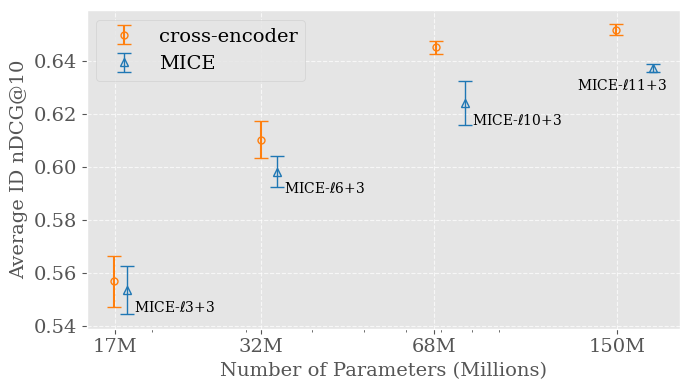

In [105]:
from matplotlib.ticker import FuncFormatter , MaxNLocator
# Now plot it 
fig, ax = plt.subplots(figsize=(7,4))

baseline_ticks = []
for xp, data in xps_dict.items():
    n_params = data['n_params']  # in millions
    mice_n_params = data['mice_n_params']  # in millions
    baseline_mean = data[baseline_mean_key]
    baseline_std = np.sqrt(data[baseline_var_key])
    mice_mean = data[mice_mean_key]
    mice_std = np.sqrt(data[mice_var_key])
    mice_label = rf"MICE-$\ell${data['fusion_layer']}+{data.get('n_upper', 'all')}"
    # (Handles cases where n_params might be a scalar or a list)

    # Plot baseline
    ax.errorbar(
        n_params,
        baseline_mean,
        yerr=baseline_std,
        fmt='o',
        color='tab:orange',
        label='cross-encoder' if xp == list(xps_dict.keys())[0] else "",
        capsize=5,
        markersize=5,
        markerfacecolor='none',
    )
    
    # Plot MICE
    ax.errorbar(
        mice_n_params,
        mice_mean,
        yerr=mice_std,
        fmt='^',
        linewidth=1,
        color='tab:blue',
        label='MICE' if xp == list(xps_dict.keys())[0] else "",
        capsize=5,
        markersize=6,
        markerfacecolor='none',
    ) 

    # --- Added Code Starts Here ---
    # Add text label lower right of the MICE point
    shift = (5, -7) if mice_n_params < 100 else (-55, -7)
    ax.annotate(
        mice_label, 
        xy=(mice_n_params, mice_mean), 
        xytext= shift,             # Shift 5 points right, 5 points down
        textcoords='offset points', # Coordinate system for the shift
        ha='left',                  # Horizontal alignment: left
        va='top',                   # Vertical alignment: top
        fontsize=10                 # Adjust font size as needed
    )
    # --- Added Code Ends Here ---


# --- Formatter Code Starts Here ---
def millions(x, pos):
    # Use :g to remove trailing zeros (e.g., 100.0 -> 100) or int(x)
    return f'{x:g}M'

ax.set_xlabel('Number of Parameters (Millions)', fontsize=FONT_SIZE)
ax.set_ylabel('Average ID nDCG@10', fontsize=FONT_SIZE)
ax.set_xscale('log')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=FONT_SIZE)
ax.set_xticks([17, 32, 68, 150])
ax.xaxis.set_major_formatter(FuncFormatter(millions))

backbone = 'ettin'
plt.tight_layout()
# Note: It is often safer to save before showing, as show() can clear the figure in some backends
fig.savefig(f'figures/parameter_scaling_ID_nDCG10_{backbone}.pdf')
plt.show()

# Compression Experiments

In [103]:
xp = "midFusion_minilm_l6_compress"


most_recent_date = get_last_xp(xp)
results_file = most_recent_date / "results" / "results.csv"
if results_file.exists():
    print(f"Results for {xp}:")
    results = pd.read_csv(results_file)
    results_dict[xp] = (results, N_LAYERS)
    
else:
    print(f"No results found for {xp}.")

def get_compress_layer(row):
    scorer = row['scorer']
    try:
        match = re.compile(r'compress=(\d+)').search(scorer)
        return int(match.group(1))
    except: 
        return None
    
results = process_results(results).copy()
results['compress_layer'] = results.apply(get_compress_layer, axis=1)

display(results.sort_values(by='compress_layer'))

aggregated_stats = get_aggregated_stats(results, ['first_stage', 'scorer', 'compress_layer'], metrics)

display(aggregated_stats)



Found dates for midFusion_minilm_l6_compress: ['20260115_190100', '20260116_095736', 'dry-run', 'lock', '20260117_135805', '20260117_220406', '20260118_104513']
Most recent date for midFusion_minilm_l6_compress: 20260118_104513
Results for midFusion_minilm_l6_compress:


,dataset,first_stage,scorer,AP_mean,AP_var,RR@10_mean,RR@10_var,nDCG@10_mean,nDCG@10_var,compress_layer
2,msmarco_dev,bm25,baseline-miniLM-compress=1_drop=11_merge=6,0.3538,6.8374866e-05,0.34946,7.476801e-05,0.40992004,7.319711e-05,1
5,trec2019,bm25,baseline-miniLM-compress=1_drop=11_merge=6,0.4889,0.0001044,0.9309,0.0026574696,0.68608,0.0007122808,1
8,trec2020,bm25,baseline-miniLM-compress=1_drop=11_merge=6,0.46157998,4.2517036e-05,0.95176,0.00015027297,0.66552,9.2466784e-05,1
3,msmarco_dev,bm25,miniLM-compress=2_drop=11_merge=6,0.33862,9.691899e-06,0.33378,1.0412032e-05,0.39288002,1.1176963e-05,2
9,trec2020,bm25,miniLM-compress=2_drop=11_merge=6,0.44576,4.900809e-05,0.94049996,0.00037516496,0.64288,0.00015742722,2
6,trec2019,bm25,miniLM-compress=2_drop=11_merge=6,0.47322002,1.01269725e-05,0.93232,0.00010475703,0.66877997,0.00025216735,2
4,msmarco_dev,bm25,miniLM-compress=3_drop=11_merge=6,0.32172,9.107031e-06,0.3159,9.059942e-06,0.37402,1.0751957e-05,3
7,trec2019,bm25,miniLM-compress=3_drop=11_merge=6,0.45728,1.984687e-05,0.91334,0.0005630583,0.6568,0.00027590027,3
10,trec2020,bm25,miniLM-compress=3_drop=11_merge=6,0.42564002,2.4113024e-05,0.92372,0.00021186688,0.61596,0.00011369307,3


AP_Grand_Mean  \
first_stage scorer                                     compress_layer                  
bm25        baseline-miniLM-compress=1_drop=11_merge=6 1                    0.434760   
            miniLM-compress=2_drop=11_merge=6          2                    0.419200   
            miniLM-compress=3_drop=11_merge=6          3                    0.401547   

                                                                       AP_Average_Var  \
first_stage scorer                                     compress_layer                   
bm25        baseline-miniLM-compress=1_drop=11_merge=6 1                     0.000072   
            miniLM-compress=2_drop=11_merge=6          2                     0.000023   
            miniLM-compress=3_drop=11_merge=6          3                     0.000018   

                                                                       RR@10_Grand_Mean  \
first_stage scorer                                     compress_layer                     
bm25        baseline-miniLM-compress=1_drop=11_merge=6 1                       0.744040   
            miniLM-compress=2_drop=11_merge=6          2                       0.735533   
            miniLM-compress=3_drop=11_merge=6          3                       0.717653   

                                                                       RR@10_Average_Var  \
first_stage scorer                                     compress_layer                      
bm25        baseline-miniLM-compress=1_drop=11_merge=6 1                        0.000961   
            miniLM-compress=2_drop=11_merge=6          2                        0.000163   
            miniLM-compress=3_drop=11_merge=6          3                        0.000261   

                                                                       nDCG@10_Grand_Mean  \
first_stage scorer                                     compress_layer                       
bm25        baseline-miniLM-compress=1_drop=11_merge=6 1                         0.587173   
            miniLM-compress=2_drop=11_merge=6          2                         0.568180   
            miniLM-compress=3_drop=11_merge=6          3                         0.548927   

                                                                       nDCG@10_Average_Var  
first_stage scorer                                     compress_layer                       
bm25        baseline-miniLM-compress=1_drop=11_merge=6 1                          0.000293  
            miniLM-compress=2_drop=11_merge=6          2                          0.000140  
            miniLM-compress=3_drop=11_merge=6          3                          0.000133

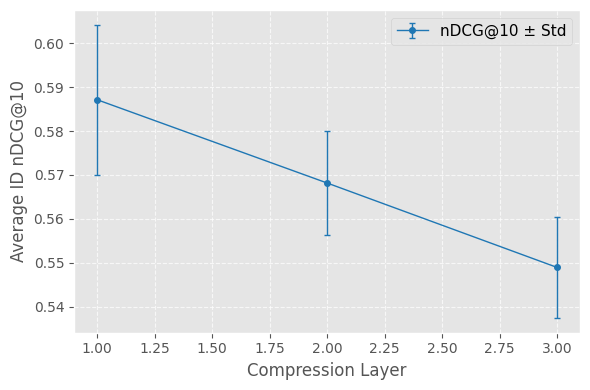

In [ ]:
# plot compress layer vs nDCG@10 Grand Mean with error bars
import numpy as np
import matplotlib.pyplot as plt

metric_to_plot = 'nDCG@10'

fig, ax = plt.subplots(figsize=(6, 4))

# Filter for plotting
plot_df = aggregated_stats.reset_index()
plot_df = plot_df[plot_df['compress_layer'].notnull()].sort_values(by='compress_layer')

# Calculate Average Standard Deviation (approx) from the Average Variance
plot_df['nDCG_std_est'] = np.sqrt(plot_df[f'{metric_to_plot}_Average_Var'])

# # Plot baseline (compress_layer = None or minimum value)
# baseline_rows = plot_df[plot_df['scorer'].str.contains('baseline', na=False)]
# if len(baseline_rows) > 0:
#     baseline_value = baseline_rows[f'{metric_to_plot}_Grand_Mean'].iloc[0]
#     baseline_std_est = np.sqrt(baseline_rows[f'{metric_to_plot}_Average_Var'].iloc[0])
    
#     ax.axhline(
#         y=baseline_value,
#         color='tab:orange',
#         linestyle='--',
#         linewidth=1,
#         label='Baseline ± Std'
#     )
#     ax.fill_between(
#         plot_df['compress_layer'],
#         baseline_value - baseline_std_est,
#         baseline_value + baseline_std_est,
#         color='tab:orange',
#         alpha=0.2,
#     )


ax.errorbar(
    plot_df['compress_layer'],
    plot_df[f'{metric_to_plot}_Grand_Mean'],
    yerr=plot_df['nDCG_std_est'],
    linewidth=1,
    color='tab:blue',
    ecolor='tab:blue',
    elinewidth=1,
    capsize=2,
    label=f'{metric_to_plot} ± Std',
    marker='o',
    markersize=4,
)

ax.set_xlabel('Compression Layer', fontsize=12)
ax.set_ylabel(f'Average ID {metric_to_plot}', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

fig.savefig(f'figures/minilm_compress_{metric_to_plot}.pdf')